In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [4]:
train_dataset = keras.utils.image_dataset_from_directory(
    r"D:\cancer-mechlearn\x-ray\train",
    image_size=(224,224),
    batch_size=32,
    label_mode="binary"
)

test_dataset = keras.utils.image_dataset_from_directory(
    r"D:\cancer-mechlearn\x-ray\test",
    image_size=(224,224),
    batch_size=32,
    label_mode="binary",
    shuffle=False
)

Found 148 files belonging to 2 classes.


Found 40 files belonging to 2 classes.


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

In [7]:
raw_train_dataset = keras.utils.image_dataset_from_directory(
    r"D:\cancer-mechlearn\x-ray\train",
    image_size=(224,224),
    batch_size=32,
    label_mode="binary"
)
print(raw_train_dataset.class_names)

Found 148 files belonging to 2 classes.


['NORMAL', 'PNEUMONIA']


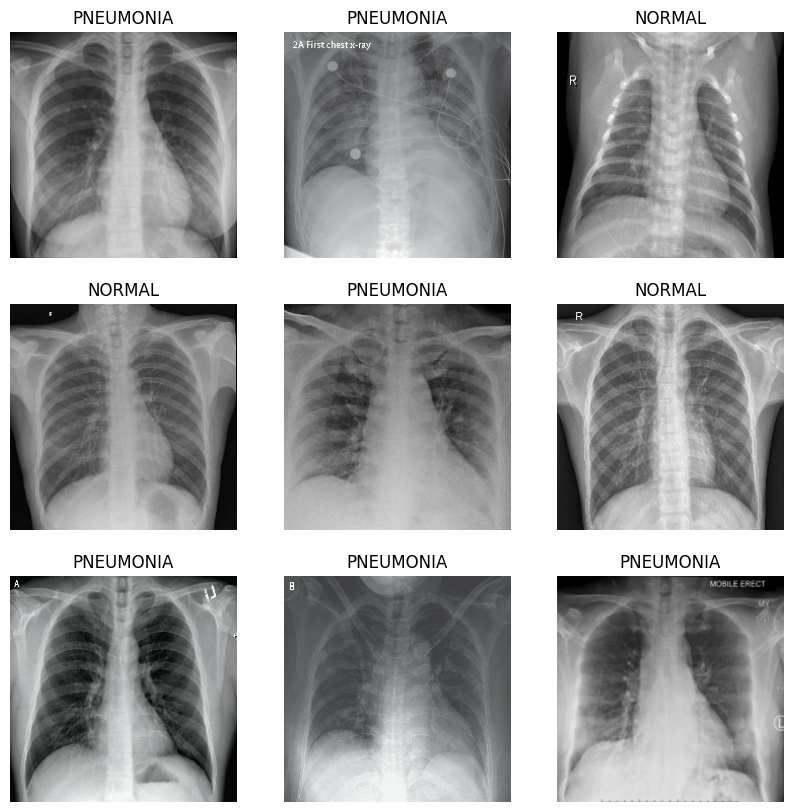

In [8]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(raw_train_dataset.class_names[int(labels[i])])
        plt.axis("off")

plt.show()

In [9]:
model = keras.Sequential([

    layers.Rescaling(1./255,input_shape=(224,224,3)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1,activation='sigmoid')

])

d:\cancer-mechlearn\venv\lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 555ms/step - accuracy: 0.5676 - loss: 0.9077 - val_accuracy: 0.9750 - val_loss: 0.5872
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 452ms/step - accuracy: 0.7297 - loss: 0.5709 - val_accuracy: 1.0000 - val_loss: 0.2908
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 469ms/step - accuracy: 0.8919 - loss: 0.2943 - val_accuracy: 0.8000 - val_loss: 0.3213
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 475ms/step - accuracy: 0.8581 - loss: 0.3386 - val_accuracy: 1.0000 - val_loss: 0.0863
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 527ms/step - accuracy: 0.8649 - loss: 0.2560 - val_accuracy: 1.0000 - val_loss: 0.0504
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 518ms/step - accuracy: 0.9527 - loss: 0.1446 - val_accuracy: 1.0000 - val_loss: 0.0380
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 515ms/step - accuracy: 0.9527 - loss: 0.0925 - val_accuracy: 1.0000 - val_loss: 0.0094
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 517ms/step - accuracy: 0.9797 - loss: 0.0606 - val_accuracy: 1.0000 - val_loss:

In [13]:
loss, accuracy = model.evaluate(test_dataset)

print("Test Accuracy:",accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.0146 
Test Accuracy: 1.0


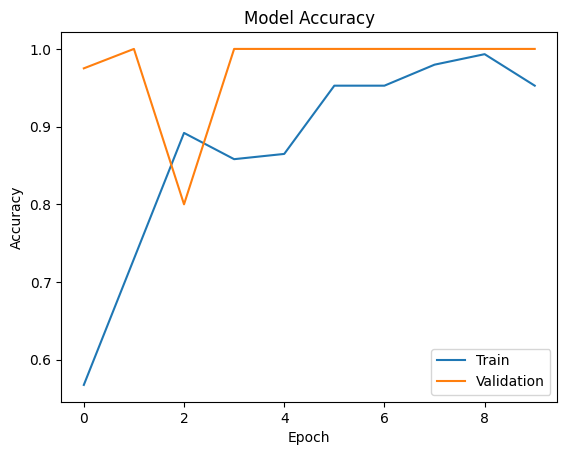

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

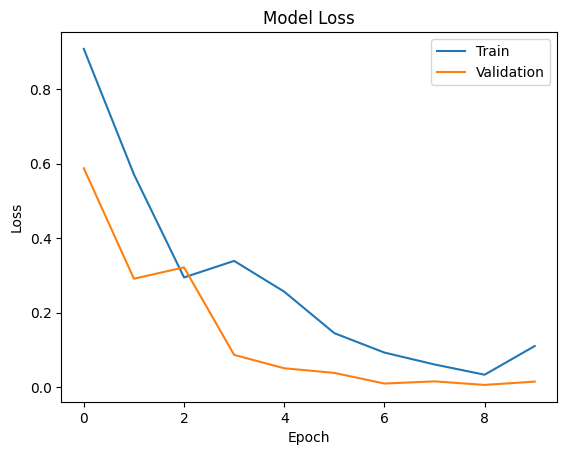

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [16]:
model.save("pneumonia_model.keras")

In [17]:
import numpy as np

img = keras.utils.load_img(
    r"D:\cancer-mechlearn\x-ray\single prediction\normal_or_pneumonia1.jpeg",
    target_size=(224,224)
)

img_array = keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array,axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction : PNEUMONIA")
else:
    print("Prediction : NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
Prediction : NORMAL
